In [4]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Configuration
# ============================================================

JSON_FILE = "results_larger.json"
VALUE_KEY = "totalNs"

N_SOURCES = 3
ARRAYS_PER_SOURCE = 20
POSITIONS = 18


# ============================================================
# 1. Load JSON
# ============================================================

with open(JSON_FILE, "r") as f:
    data = json.load(f)

print(f"Number of inner arrays: {len(data)}")
print(f"Objects per inner array: {len(data[0])}")


# ============================================================
# 2. Validate input
# ============================================================

assert len(data) == N_SOURCES * ARRAYS_PER_SOURCE, \
    f"Expected {N_SOURCES * ARRAYS_PER_SOURCE} inner arrays"

assert all(len(arr) == POSITIONS for arr in data), \
    f"Every inner array should contain {POSITIONS} objects"

assert all(VALUE_KEY in obj for arr in data for obj in arr), \
    f"Every object must contain '{VALUE_KEY}'"


# ============================================================
# 3. Split into sources
# ============================================================

sources = {
    "MongoDB": data[0:20],
    "Neo4j": data[20:40],
    "PostgreSQL": data[40:60],
}


# ============================================================
# 4. Transpose each source
#
# source1[position] contains the 20 values corresponding
# to that position across the 20 arrays.
# ============================================================

values = {}

for source_name, arrays in sources.items():

    values[source_name] = []

    for position in range(POSITIONS):

        position_values = [
            arr[position][VALUE_KEY]
            for arr in arrays
        ]

        values[source_name].append(position_values)


# ============================================================
# 5. Outlier removal
#
# Using IQR (Interquartile Range).
#
# Values outside:
#
#     Q1 - 1.5 * IQR
#     Q3 + 1.5 * IQR
#
# are treated as outliers.
# ============================================================

def remove_outliers_iqr(data):

    data = np.asarray(data, dtype=float)

    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (data >= lower) & (data <= upper)

    return data[mask], data[~mask]


# ============================================================
# 6. Calculate statistics
# ============================================================

results = []

for position in range(POSITIONS):

    for source_name in sources:

        raw = values[source_name][position]

        filtered, outliers = remove_outliers_iqr(raw)

        results.append({
            "position": position + 1,
            "source": source_name,
            "mean": np.mean(filtered),
            "median": np.median(filtered),
            "std": np.std(filtered, ddof=1) if len(filtered) > 1 else 0,
            "count": len(filtered),
            "outliers": len(outliers),
            "min": np.min(filtered),
            "max": np.max(filtered),
        })


results_df = pd.DataFrame(results)

results_df

Number of inner arrays: 60
Objects per inner array: 18


,position,source,mean,median,std,count,outliers,min,max
0,1,MongoDB,6.060477e+06,5.178304e+06,2.607766e+06,19,1,3.338353e+06,1.153286e+07
1,1,Neo4j,1.438986e+07,1.428073e+07,3.156542e+06,17,3,9.886922e+06,2.019938e+07
2,1,PostgreSQL,2.600084e+06,2.548185e+06,8.037445e+05,19,1,1.516447e+06,4.255218e+06
3,2,MongoDB,2.154769e+06,1.983401e+06,7.804276e+05,19,1,1.254885e+06,4.182608e+06
4,2,Neo4j,2.751245e+07,2.226081e+07,1.275369e+07,19,1,1.447744e+07,5.683081e+07
5,2,PostgreSQL,4.256162e+06,3.735101e+06,1.523645e+06,18,2,2.064155e+06,7.076630e+06
6,3,MongoDB,5.029255e+06,4.956253e+06,1.358403e+06,19,1,2.531796e+06,7.659049e+06
7,3,Neo4j,1.825322e+07,1.535764e+07,7.038442e+06,19,1,1.008238e+07,3.237831e+07
8,3,PostgreSQL,2.269975e+06,2.215789e+06,1.002775e+06,19,1,9.627630e+05,4.591155e+06
9,4,MongoDB,9.168018e+06,8.582129e+06,2.583613e+06,18,2,6.141027e+06,1.342043e+07


In [5]:
comparison = results_df.pivot(
    index="position",
    columns="source",
    values="mean"
)

relative = comparison.div(
    comparison.min(axis=1),
    axis=0
)

relative

source,MongoDB,Neo4j,PostgreSQL
position,,,
1,2.330877,5.534383,1.000000
2,1.000000,12.768170,1.975229
3,2.215556,8.041155,1.000000
4,1.000000,12.755439,1.140256
5,1.572447,5.201439,1.000000
6,1.650289,6.197568,1.000000
7,7.008054,4.527285,1.000000
8,36.969529,3.260506,1.000000
9,44.712666,1.703104,1.000000


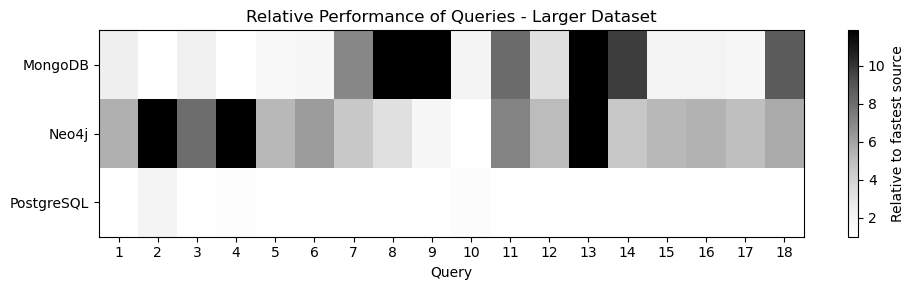

In [6]:
from matplotlib.colors import Normalize
import numpy as np

vmin = 1.0

# Ignore the extreme upper values when defining the color scale
vmax = np.percentile(relative.values, 90)

plt.figure(figsize=(10, 3))

plt.imshow(
    relative.values.T,
    aspect="auto",
    cmap="Greys",
    norm=Normalize(vmin=vmin, vmax=vmax)
)

cbar = plt.colorbar()
cbar.set_label("Relative to fastest source")

plt.xticks(
    range(len(relative.index)),
    relative.index
)

plt.yticks(
    range(len(relative.columns)),
    relative.columns
)

plt.xlabel("Query")
plt.title("Relative Performance of Queries - Larger Dataset")

plt.tight_layout()

plt.savefig("queries_performance_larger.png", dpi=300, bbox_inches="tight")

plt.show()